# Trade-Level Behavioral Feature Engineering for FOMO Detection

**Objective:**  
Generate behavioral features describing the **state of an investor at the moment each trade occurs**.

**Core Insight:**  
FOMO is a **temporary behavioral state**, not a permanent personality trait. A disciplined investor can exhibit FOMO during a bull-run and revert to rational behavior afterwards. Therefore the unit of analysis is the **individual trade**, not the investor.

**Output:**  
`trade_behavior_features.csv` — one row per trade, enriched with ~100 behavioral signals across 5 families.

**Pipeline:**
1. Data loading, merge, and temporal preparation  
2. Group 1 — Trend-Chasing Behavior  
3. Group 2 — Position Sizing Instability  
4. Group 3 — Behavioral Velocity  
5. Group 4 — Execution Context  
6. Group 5 — Market FOMO Pressure (Herding Signals)  
7. Rolling investor features  
8. Automatic feature generation (z-score, percentile, rolling stats)  
9. Feature diagnostics pipeline (transform → variance → Spearman → VIF → PCA)  
10. Export

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', 60)

## 2. Data Loading & Preparation

Both source files are loaded. `market_data.csv` carries a longer history (from 2020-01-01) which allows computing asset-level historical statistics needed for percentile ranks and z-scores.

**Key note on timestamps:** All timestamps in this dataset contain **date only** (no hour/minute resolution).  
All temporal features are therefore computed at **daily resolution**.

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────
trades = pd.read_csv('data/output/enriched_trades_train.csv')
market = pd.read_csv('data/output/market_data.csv')

trades = trades.rename(columns={'totalValue': 'total_value'})

trades['timestamp'] = pd.to_datetime(trades['timestamp'])
market['timestamp'] = pd.to_datetime(market['timestamp'])

trades = trades.sort_values(['investor_id', 'timestamp']).reset_index(drop=True)
market = market.sort_values(['asset_id', 'timestamp']).reset_index(drop=True)

print(f"Trades : {trades.shape[0]:,} rows × {trades.shape[1]} cols")
print(f"Market : {market.shape[0]:,} rows × {market.shape[1]} cols")
print(f"Investors  : {trades['investor_id'].nunique():,}")
print(f"Assets     : {trades['asset_id'].nunique():,}")
print(f"Date range : {trades['timestamp'].min().date()} → {trades['timestamp'].max().date()}")

Trades : 199,932 rows × 21 cols
Market : 193,040 rows × 11 cols
Investors  : 13,474
Assets     : 174
Date range : 2020-07-01 → 2022-11-30


### 2.1 Extend market_data with multi-day returns

The trades dataset already contains `return_1d` and `return_5d`. We enrich market_data with  
`return_3d` and `return_10d` using price pct_change, then join to trades.

In [3]:
# ── Compute 3-day and 10-day returns from market_data ────────────────────
market['return_3d']  = market.groupby('asset_id')['market_price'].pct_change(3)
market['return_10d'] = market.groupby('asset_id')['market_price'].pct_change(10)

# ── Merge extra return columns into trades ────────────────────────────────
df = trades.merge(
    market[['asset_id', 'timestamp', 'return_3d', 'return_10d']],
    on=['asset_id', 'timestamp'],
    how='left'
)

print(f"df shape after merge : {df.shape}")
print(f"return_3d  nulls : {df['return_3d'].isna().sum():,}")
print(f"return_10d nulls : {df['return_10d'].isna().sum():,}")

df shape after merge : (199932, 23)
return_3d  nulls : 1,543
return_10d nulls : 1,842


### 2.2 Temporal features

In [4]:
# ── Temporal features ─────────────────────────────────────────────────────
df['day_of_week'] = df['timestamp'].dt.dayofweek   # 0=Mon … 6=Sun
df['month']       = df['timestamp'].dt.month
df['trade_date']  = df['timestamp'].dt.date

# ── Per-investor trade gap (days between consecutive trades) ──────────────
df['trade_gap_days'] = (
    df.groupby('investor_id')['timestamp']
      .diff()
      .dt.days
      .fillna(0)
)

# ── Per-investor running trade index ─────────────────────────────────────
df['investor_trade_index'] = df.groupby('investor_id').cumcount() + 1

# ── Investor total trade count (for filtering rolling features) ───────────
investor_trade_count = df.groupby('investor_id').size().rename('investor_total_trades')
df = df.merge(investor_trade_count, on='investor_id', how='left')

print("Temporal features created:")
print(df[['trade_date','day_of_week','month','trade_gap_days','investor_trade_index',
          'investor_total_trades']].describe().round(2))

Temporal features created:
       day_of_week      month  trade_gap_days  investor_trade_index  \
count    199932.00  199932.00       199932.00             199932.00   
mean          1.96       6.65           13.99                140.86   
std           1.41       3.47           44.53                274.60   
min           0.00       1.00            0.00                  1.00   
25%           1.00       3.00            0.00                  9.00   
50%           2.00       7.00            1.00                 37.00   
75%           3.00      10.00            7.00                134.00   
max           4.00      12.00          831.00               2411.00   

       investor_total_trades  
count              199932.00  
mean                  280.73  
std                   454.45  
min                     1.00  
25%                    27.00  
50%                    95.00  
75%                   299.00  
max                  2411.00  


## 3. Group 1 — Trend-Chasing Behavior

**Behavioral theory:** FOMO investors buy assets that are already overbought — they chase momentum rather than anticipate it.  
These features capture the *market conditions at the exact moment a trade is placed*.

In [5]:
# ── G1.1: buy_in_overbought_zone ──────────────────────────────────────────
# 1 if this is a BUY trade and RSI > 70 at that moment
df['buy_in_overbought_zone'] = (
    (df['side'] == 'BUY') & (df['rsi_14'] > 70)
).astype(int)

# ── G1.2: extreme_overbought_flag ─────────────────────────────────────────
# 1 if RSI > 80 — extreme overbought territory
df['extreme_overbought_flag'] = (df['rsi_14'] > 80).astype(int)

# ── G1.3: rsi_distance_from_neutral ───────────────────────────────────────
# |RSI - 50|: how far from the neutral zone.
# High = investor trades in strongly trending (or exhausted) conditions.
df['rsi_distance_from_neutral'] = (df['rsi_14'] - 50).abs()

# ── G1.4: price_above_ma20_zscore ─────────────────────────────────────────
# Z-score of price_above_ma20 per asset — normalises for cross-asset comparisons.
# A high value at BUY time = buying well above average relative price.
df['price_above_ma20_zscore'] = df.groupby('asset_id')['price_above_ma20'].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-8)
)

# ── G1.5: extreme_momentum_flag ───────────────────────────────────────────
# 1 if the asset's 5-day return is above its own 90th historical percentile.
# Uses all available market history (not just trade dates) via market_data ranks.
asset_return5_p90 = df.groupby('asset_id')['return_5d'].transform(
    lambda x: x.quantile(0.9)
)
df['extreme_momentum_flag'] = (df['return_5d'] > asset_return5_p90).astype(int)

# ── G1.6: momentum_acceleration ───────────────────────────────────────────
# return_3d − return_10d: positive = momentum gaining speed recently.
# FOMO investors enter just as momentum accelerates, not at the start.
df['momentum_acceleration'] = df['return_3d'].fillna(0) - df['return_10d'].fillna(0)

print("Group 1 — Trend-Chasing features created:")
g1_cols = ['buy_in_overbought_zone','extreme_overbought_flag','rsi_distance_from_neutral',
           'price_above_ma20_zscore','extreme_momentum_flag','momentum_acceleration']
print(df[g1_cols].describe().round(4))

Group 1 — Trend-Chasing features created:
       buy_in_overbought_zone  extreme_overbought_flag  \
count             199932.0000              199932.0000   
mean                   0.0467                   0.0168   
std                    0.2109                   0.1284   
min                    0.0000                   0.0000   
25%                    0.0000                   0.0000   
50%                    0.0000                   0.0000   
75%                    0.0000                   0.0000   
max                    1.0000                   1.0000   

       rsi_distance_from_neutral  price_above_ma20_zscore  \
count                197840.0000              199652.0000   
mean                     11.8418                  -0.0000   
std                       8.1219                   0.9995   
min                       0.0001                  -4.5113   
25%                       5.0789                  -0.6515   
50%                      10.7829                  -0.0509   
75%     

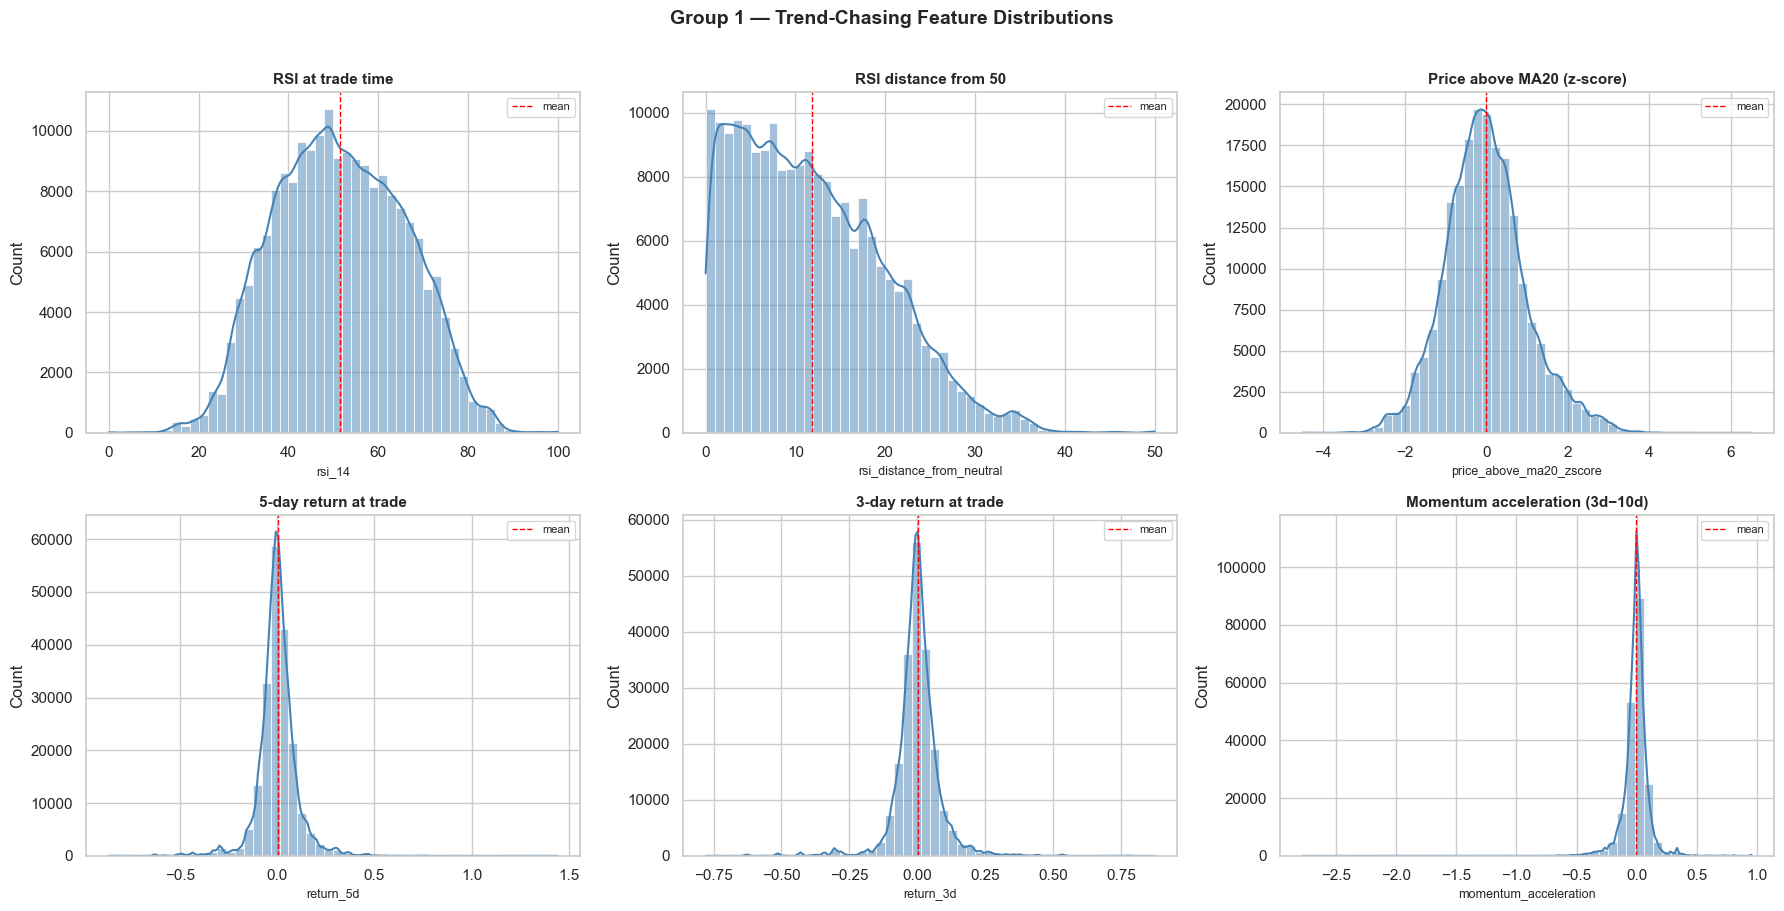

In [6]:
# ── Visualise Group 1 distributions ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
g1_plot = [
    ('rsi_14',                  'RSI at trade time'),
    ('rsi_distance_from_neutral','RSI distance from 50'),
    ('price_above_ma20_zscore', 'Price above MA20 (z-score)'),
    ('return_5d',               '5-day return at trade'),
    ('return_3d',               '3-day return at trade'),
    ('momentum_acceleration',   'Momentum acceleration (3d−10d)'),
]
for ax, (col, title) in zip(axes.flatten(), g1_plot):
    data = df[col].dropna()
    sns.histplot(data, kde=True, ax=ax, color='steelblue', bins=50)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1, label='mean')
    ax.legend(fontsize=8)
plt.suptitle('Group 1 — Trend-Chasing Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Group 2 — Position Sizing Instability

**Behavioral theory:** Disciplined investors size positions consistently relative to their capacity.  
FOMO investors break this discipline — they over-size positions when chasing hot assets.

Rolling statistics use `shift(1)` to ensure **no look-ahead bias**: each feature only uses  
information available before the current trade.

Features requiring rolling history are only populated for investors with **≥ 20 trades** in total.

In [7]:
# ── G2.1: rolling_position_size_zscore ────────────────────────────────────
# Z-score of current position_size_ratio relative to investor's own 20-trade rolling history.
# shift(1) prevents look-ahead: the current trade is not included in the mean/std.
rolling_pos_mean = df.groupby('investor_id')['position_size_ratio'].transform(
    lambda x: x.shift(1).rolling(20, min_periods=5).mean()
)
rolling_pos_std = df.groupby('investor_id')['position_size_ratio'].transform(
    lambda x: x.shift(1).rolling(20, min_periods=5).std()
)
df['rolling_position_size_zscore'] = (
    (df['position_size_ratio'] - rolling_pos_mean) / (rolling_pos_std + 1e-8)
)
# Only meaningful for investors with >= 20 total trades
df.loc[df['investor_total_trades'] < 20, 'rolling_position_size_zscore'] = np.nan

# ── G2.2: position_size_spike_flag ────────────────────────────────────────
# 1 if current position exceeds investor's own 95th percentile of past sizing.
pos_p95 = df.groupby('investor_id')['position_size_ratio'].transform(
    lambda x: x.shift(1).expanding(min_periods=5).quantile(0.95)
)
df['position_size_spike_flag'] = (df['position_size_ratio'] > pos_p95).astype(int)
df.loc[df['investor_total_trades'] < 20, 'position_size_spike_flag'] = np.nan

# ── G2.3: capital_acceleration_ratio ──────────────────────────────────────
# current_trade_value / rolling_mean_trade_value_last_10_trades.
# > 1.0 means investor is deploying more capital than their recent average.
rolling_tv_mean_10 = df.groupby('investor_id')['total_value'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=3).mean()
)
df['capital_acceleration_ratio'] = df['total_value'] / (rolling_tv_mean_10 + 1e-8)
df.loc[df['investor_total_trades'] < 10, 'capital_acceleration_ratio'] = np.nan

# ── G2.4: position_size_to_volatility_ratio ───────────────────────────────
# position_size_ratio / volatility_5d.
# FOMO signal: high position size in a high-volatility asset (counter to risk management).
df['position_size_to_volatility_ratio'] = (
    df['position_size_ratio'] / (df['volatility_5d'] + 1e-8)
)

print("Group 2 — Position Sizing Instability features created:")
g2_cols = ['rolling_position_size_zscore','position_size_spike_flag',
           'capital_acceleration_ratio','position_size_to_volatility_ratio']
print(df[g2_cols].describe().round(4))

Group 2 — Position Sizing Instability features created:
       rolling_position_size_zscore  position_size_spike_flag  \
count                   150258.0000                159627.000   
mean                         0.1635                     0.092   
std                          2.0021                     0.289   
min                        -46.5199                     0.000   
25%                         -0.6752                     0.000   
50%                         -0.2156                     0.000   
75%                          0.5710                     0.000   
max                        197.3563                     1.000   

       capital_acceleration_ratio  position_size_to_volatility_ratio  
count                 165572.0000                       1.979970e+05  
mean                       1.1598                       1.554341e+04  
std                        5.0645                       9.066009e+05  
min                        0.0000                       0.000000e+00  
25%

## 5. Group 3 — Behavioral Velocity

**Behavioral theory:** FOMO-driven trading is impulsive — investors cluster trades in short bursts.  
Since the dataset has **daily resolution only**, velocity is measured via trade gaps, same-day frequency,  
and rolling trade counts rather than intraday intervals.

In [8]:
# ── G3.1: same_day_multiple_flag ─────────────────────────────────────────
# 1 if investor placed more than one trade on this calendar day.
trades_per_inv_day = (
    df.groupby(['investor_id', 'trade_date'])
      .size()
      .reset_index(name='trades_per_investor_per_day')
)
df = df.merge(trades_per_inv_day, on=['investor_id', 'trade_date'], how='left')
df['same_day_multiple_flag'] = (df['trades_per_investor_per_day'] > 1).astype(int)

# ── G3.2: rolling_trade_frequency_last_5_trades ───────────────────────────
# Average daily trade gap over last 5 trades (lower = more frequent = more impulsive).
# Computed as: 5 / (sum of last 5 trade_gap_days), clipped to avoid division by zero.
df['rolling_trade_freq_5'] = df.groupby('investor_id')['trade_gap_days'].transform(
    lambda x: 1 / (x.shift(1).rolling(5, min_periods=2).mean().clip(lower=1) )
)

# ── G3.3: consecutive_buy_streak ─────────────────────────────────────────
# Number of consecutive BUY trades up to and including this one.
# Resets to 1 on each SELL (or 0 if the current trade is SELL).
def consecutive_buy_streak(series):
    result = []
    streak = 0
    for v in series:
        streak = streak + 1 if v == 1 else 0
        result.append(streak)
    return result

df['is_buy_int'] = (df['side'] == 'BUY').astype(int)
df['consecutive_buy_streak'] = df.groupby('investor_id')['is_buy_int'].transform(
    lambda x: pd.Series(consecutive_buy_streak(x.values), index=x.index)
)

print("Group 3 — Behavioral Velocity features created:")
g3_cols = ['trade_gap_days','trades_per_investor_per_day','same_day_multiple_flag',
           'rolling_trade_freq_5','consecutive_buy_streak']
print(df[g3_cols].describe().round(4))

Group 3 — Behavioral Velocity features created:
       trade_gap_days  trades_per_investor_per_day  same_day_multiple_flag  \
count     199932.0000                  199932.0000             199932.0000   
mean          13.9934                       2.5174                  0.5456   
std           44.5252                       2.5526                  0.4979   
min            0.0000                       1.0000                  0.0000   
25%            0.0000                       1.0000                  0.0000   
50%            1.0000                       2.0000                  1.0000   
75%            7.0000                       3.0000                  1.0000   
max          831.0000                      47.0000                  1.0000   

       rolling_trade_freq_5  consecutive_buy_streak  
count           178282.0000             199932.0000  
mean                 0.4338                  2.0200  
std                  0.3839                  5.5115  
min                  0.0024      

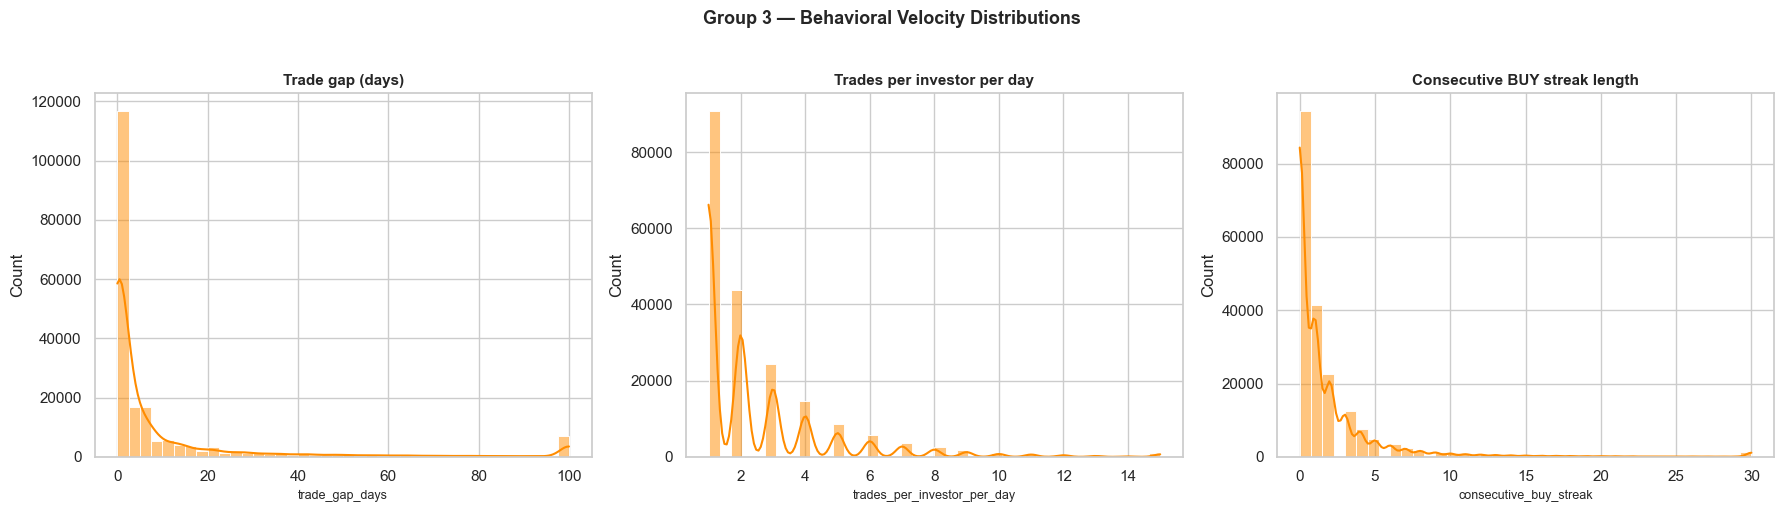

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title, clip) in zip(axes, [
    ('trade_gap_days',             'Trade gap (days)',                     100),
    ('trades_per_investor_per_day','Trades per investor per day',           15),
    ('consecutive_buy_streak',     'Consecutive BUY streak length',         30),
]):
    data = df[col].clip(upper=clip)
    sns.histplot(data, kde=True, ax=ax, color='darkorange', bins=40)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
plt.suptitle('Group 3 — Behavioral Velocity Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Group 4 — Execution Context

**Behavioral theory:** External conditions at execution time modulate FOMO behavior.  
These features capture the *environment* of each trade — channel, volatility regime, and trend alignment.

In [10]:
# ── G4.1: digital_trade_flag ──────────────────────────────────────────────
# 1 if trade placed via Internet Banking (lowest friction channel = most impulsive).
df['digital_trade_flag'] = (df['channel'] == 'Internet Banking').astype(int)

# ── G4.2: volatility_pressure ─────────────────────────────────────────────
# volatility_5d normalised by the asset's historical mean volatility.
# > 1.0 = current volatility exceeds asset's own norm — high-stress environment.
asset_mean_vol = df.groupby('asset_id')['volatility_5d'].transform('mean')
df['volatility_pressure'] = df['volatility_5d'] / (asset_mean_vol + 1e-8)

# ── G4.3: market_trend_indicator ─────────────────────────────────────────
# 1 if asset price is above MA20 (uptrend).
df['market_trend_indicator'] = (df['price_above_ma20'] > 1.0).astype(int)

# ── G4.4: volatility_regime ───────────────────────────────────────────────
# Ratio of short-term to long-term volatility: volatility_5d / volatility_10d.
# > 1 = volatility spike (market becoming more uncertain recently).
df['volatility_regime'] = df['volatility_5d'] / (df['volatility_10d'] + 1e-8)

# ── G4.5: ma_compression ──────────────────────────────────────────────────
# ma_5d / ma_20d: ratio of short vs long moving average.
# > 1 = price recently accelerating upward relative to long-term trend.
df['ma_compression'] = df['ma_5d'] / (df['ma_20d'] + 1e-8)

print("Group 4 — Execution Context features created:")
g4_cols = ['digital_trade_flag','day_of_week','volatility_pressure',
           'market_trend_indicator','volatility_regime','ma_compression']
print(df[g4_cols].describe().round(4))

Group 4 — Execution Context features created:
       digital_trade_flag  day_of_week  volatility_pressure  \
count         199932.0000  199932.0000          198327.0000   
mean               0.7538       1.9592               0.9998   
std                0.4308       1.4138               0.6679   
min                0.0000       0.0000               0.0000   
25%                1.0000       1.0000               0.5577   
50%                1.0000       2.0000               0.8325   
75%                1.0000       3.0000               1.2411   
max                1.0000       4.0000              15.0000   

       market_trend_indicator  volatility_regime  ma_compression  
count             199932.0000        198090.0000     199654.0000  
mean                   0.5135             0.9893          1.0029  
std                    0.4998             0.3042          0.0810  
min                    0.0000             0.0000          0.2094  
25%                    0.0000             0.7726   

## 7. Group 5 — Market FOMO Pressure (Herding Signals)

**Behavioral theory:** FOMO is contagious. When many investors crowd into the same asset on the same day,  
the crowd pressure increases the probability that any given trade is FOMO-driven.  
These features measure *how popular an asset is at the exact day of each trade*.

In [11]:
# ── Asset same-day aggregates ─────────────────────────────────────────────
asset_day_agg = (
    df.groupby(['asset_id', 'timestamp'])
      .agg(
          asset_trade_count_same_day  = ('side', 'count'),
          asset_buy_ratio_same_day    = ('side', lambda x: (x == 'BUY').mean()),
          asset_buy_volume_same_day   = ('total_value',
                                        lambda x: x[df.loc[x.index,'side'] == 'BUY'].sum()),
      )
      .reset_index()
)
df = df.merge(asset_day_agg, on=['asset_id', 'timestamp'], how='left')

# ── G5.1: asset_popularity_zscore ─────────────────────────────────────────
# Z-score of asset_trade_count_same_day relative to that asset's historical activity.
df['asset_popularity_zscore'] = df.groupby('asset_id')['asset_trade_count_same_day'].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-8)
)

# ── G5.2: investor_alignment_with_crowd ──────────────────────────────────
# 1 if investor BUYs when > 70% of trades on that asset that day are BUYs.
df['investor_alignment_with_crowd'] = (
    (df['side'] == 'BUY') & (df['asset_buy_ratio_same_day'] > 0.7)
).astype(int)

# ── G5.3: market_fomo_pressure_score ──────────────────────────────────────
# Composite index: momentum percentile (40%) + crowd buy pressure (40%) + asset popularity (20%).
# All components normalised to [0, 1] before combining.
ret5_pctrank = df.groupby('asset_id')['return_5d'].transform(
    lambda x: x.rank(pct=True)
).fillna(0.5)

buy_ratio_norm = df['asset_buy_ratio_same_day'].fillna(0.5)

pop_min = df['asset_popularity_zscore'].min()
pop_max = df['asset_popularity_zscore'].max()
pop_norm = (df['asset_popularity_zscore'] - pop_min) / (pop_max - pop_min + 1e-8)

df['market_fomo_pressure_score'] = (
    0.40 * ret5_pctrank +
    0.40 * buy_ratio_norm +
    0.20 * pop_norm.fillna(0.5)
)

print("Group 5 — Market FOMO Pressure features created:")
g5_cols = ['asset_trade_count_same_day','asset_buy_ratio_same_day',
           'asset_buy_volume_same_day','asset_popularity_zscore',
           'investor_alignment_with_crowd','market_fomo_pressure_score']
print(df[g5_cols].describe().round(4))

Group 5 — Market FOMO Pressure features created:
       asset_trade_count_same_day  asset_buy_ratio_same_day  \
count                 199932.0000               199932.0000   
mean                      29.5492                    0.5275   
std                       66.8291                    0.2908   
min                        1.0000                    0.0000   
25%                        4.0000                    0.3333   
50%                       11.0000                    0.5357   
75%                       30.0000                    0.7500   
max                      720.0000                    1.0000   

       asset_buy_volume_same_day  asset_popularity_zscore  \
count               1.999320e+05              199930.0000   
mean                6.315219e+04                   0.0000   
std                 1.292233e+05                   0.9993   
min                 0.000000e+00                  -1.6844   
25%                 2.859400e+03                  -0.6188   
50%              

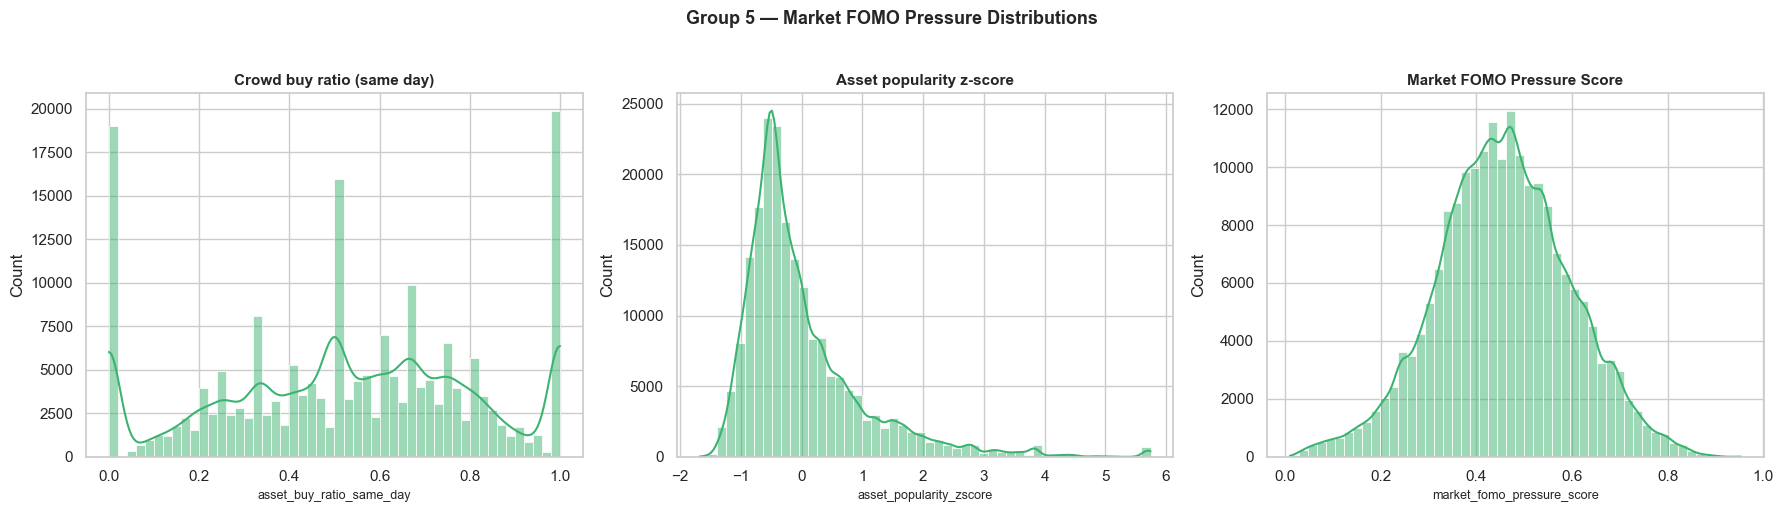

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title) in zip(axes, [
    ('asset_buy_ratio_same_day',     'Crowd buy ratio (same day)'),
    ('asset_popularity_zscore',      'Asset popularity z-score'),
    ('market_fomo_pressure_score',   'Market FOMO Pressure Score'),
]):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='mediumseagreen', bins=50)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
plt.suptitle('Group 5 — Market FOMO Pressure Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Rolling Investor Behavioral Features

Rolling windows give each trade a **backward-looking behavioral profile** of its investor.  
All windows use `shift(1)` to avoid look-ahead bias.

| Window | Trades used | Minimum observations |
|--------|-------------|----------------------|
| 5 trades | last 5 | 2 |
| 10 trades | last 10 | 3 |
| 20 trades | last 20 | 5 |

In [13]:
# ── Helper: grouped rolling with shift(1) ─────────────────────────────────
def inv_roll(col, window, func='mean', min_p=None):
    """Rolling statistic over last `window` trades per investor (shift=1, no look-ahead)."""
    if min_p is None:
        min_p = max(2, window // 4)
    return df.groupby('investor_id')[col].transform(
        lambda x: getattr(x.shift(1).rolling(window, min_periods=min_p), func)()
    )

# ── Rolling buy ratios ──────────────────────────────────────────────────────
df['rolling_buy_ratio_last_5_trades']  = inv_roll('is_buy_int', 5)
df['rolling_buy_ratio_last_10_trades'] = inv_roll('is_buy_int', 10)
df['rolling_buy_ratio_last_20_trades'] = inv_roll('is_buy_int', 20)

# ── Rolling average position size ─────────────────────────────────────────
df['rolling_avg_position_size_last_10_trades'] = inv_roll('position_size_ratio', 10)
df['rolling_avg_position_size_last_20_trades'] = inv_roll('position_size_ratio', 20)

# ── Rolling momentum exposure (mean return_5d at time of trade) ──────────
df['return_5d_filled'] = df['return_5d'].fillna(0)
df['rolling_momentum_exposure_last_5_trades']  = inv_roll('return_5d_filled', 5)
df['rolling_momentum_exposure_last_10_trades'] = inv_roll('return_5d_filled', 10)

# ── Rolling volatility exposure (mean volatility_5d) ─────────────────────
df['rolling_volatility_exposure_last_10_trades'] = inv_roll('volatility_5d', 10)
df['rolling_volatility_exposure_last_20_trades'] = inv_roll('volatility_5d', 20)

# ── Rolling RSI exposure ───────────────────────────────────────────────────
df['rsi_14_filled'] = df['rsi_14'].fillna(50)
df['rolling_rsi_exposure_last_10_trades'] = inv_roll('rsi_14_filled', 10)

# ── Rolling overbought frequency ──────────────────────────────────────────
df['rolling_overbought_freq_last_10_trades'] = inv_roll('buy_in_overbought_zone', 10)

# ── Rolling trade gap mean (speed of recent trading) ──────────────────────
df['rolling_avg_trade_gap_last_5_trades']  = inv_roll('trade_gap_days', 5)
df['rolling_avg_trade_gap_last_10_trades'] = inv_roll('trade_gap_days', 10)

rolling_cols = [c for c in df.columns if c.startswith('rolling_')]
print(f"Rolling features created: {len(rolling_cols)}")
print(df[rolling_cols].notna().mean().round(3).to_string())

Rolling features created: 15
rolling_position_size_zscore                  0.752
rolling_trade_freq_5                          0.892
rolling_buy_ratio_last_5_trades               0.892
rolling_buy_ratio_last_10_trades              0.892
rolling_buy_ratio_last_20_trades              0.811
rolling_avg_position_size_last_10_trades      0.891
rolling_avg_position_size_last_20_trades      0.811
rolling_momentum_exposure_last_5_trades       0.892
rolling_momentum_exposure_last_10_trades      0.892
rolling_volatility_exposure_last_10_trades    0.890
rolling_volatility_exposure_last_20_trades    0.809
rolling_rsi_exposure_last_10_trades           0.892
rolling_overbought_freq_last_10_trades        0.892
rolling_avg_trade_gap_last_5_trades           0.892
rolling_avg_trade_gap_last_10_trades          0.892


## 9. Automatic Feature Generation

For every meaningful numeric column in the merged dataset, we automatically generate:
- **z-score** (deviation from asset-level mean — cross-asset normalisation)
- **percentile rank** (where this value sits in the asset's full distribution)
- **rolling mean** (investor's 10-trade personal average for that signal)
- **rolling std** (investor's consistency in that signal over 10 trades)

This ensures no base signal from either dataset is discarded.

In [14]:
# ── Base numeric columns to auto-expand ──────────────────────────────────
AUTO_BASE_COLS = [
    'price', 'quantity', 'total_value',
    'risk_level', 'investment_capacity_ordinal', 'position_size_ratio',
    'market_price', 'return_1d', 'return_5d', 'return_3d', 'return_10d',
    'volatility_5d', 'volatility_10d',
    'ma_5d', 'ma_20d', 'price_above_ma20', 'rsi_14',
]

auto_created = []
for col in AUTO_BASE_COLS:
    if col not in df.columns or df[col].isna().all():
        continue
    filled = df[col].fillna(df[col].median())

    # z-score per asset (cross-asset normalisation)
    z_col = f'{col}_zscore_asset'
    df[z_col] = df.groupby('asset_id')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )

    # percentile rank per asset
    pct_col = f'{col}_pctrank_asset'
    df[pct_col] = df.groupby('asset_id')[col].transform(
        lambda x: x.rank(pct=True)
    )

    # rolling mean over last 10 investor trades
    rmean_col = f'{col}_rolling_mean_10'
    df[rmean_col] = df.groupby('investor_id')[col].transform(
        lambda x: x.shift(1).rolling(10, min_periods=3).mean()
    )

    # rolling std over last 10 investor trades
    rstd_col = f'{col}_rolling_std_10'
    df[rstd_col] = df.groupby('investor_id')[col].transform(
        lambda x: x.shift(1).rolling(10, min_periods=3).std()
    )

    auto_created.extend([z_col, pct_col, rmean_col, rstd_col])

print(f"Auto-generated features: {len(auto_created)}")
print(f"Total columns in df: {df.shape[1]}")

Auto-generated features: 68
Total columns in df: 138


## 10. Assemble Feature Matrix

Collect all engineered features into a clean matrix.  
The identifier columns (`investor_id`, `asset_id`, `timestamp`, `side`) are retained for traceability  
but are not included in the feature matrix passed to the diagnostics pipeline.

In [15]:
# ── Identifier columns (kept for traceability, not used as features) ───────
ID_COLS = ['tx_id','investor_id', 'asset_id', 'timestamp', 'side',
           'channel', 'investor_total_trades', 'investor_trade_index']

# ── Explicitly exclude intermediate / redundant helper columns ─────────────
EXCLUDE = ['is_buy_int', 'return_5d_filled', 'rsi_14_filled',
           'total_value', 'trade_date' ]   # raw — superseded by z-score/pctrank versions


# ── Collect all feature columns ───────────────────────────────────────────
all_feature_cols = [
    c for c in df.columns
    if c not in ID_COLS + EXCLUDE
    and df[c].dtype in [np.float64, np.int64, float, int]
]

print(f"Feature columns selected: {len(all_feature_cols)}")

# ── Build feature dataframe ───────────────────────────────────────────────
feat_df = df[ID_COLS + all_feature_cols].copy()

# ── Report null rates ─────────────────────────────────────────────────────
null_pct = feat_df[all_feature_cols].isna().mean().sort_values(ascending=False)
high_null = null_pct[null_pct > 0.30]
print(f"\nFeatures with >30% nulls (will be dropped in diagnostics): {len(high_null)}")
if len(high_null):
    print(high_null.round(3).to_string())

# Drop columns with >30% nulls — not enough signal at trade level
drop_high_null = high_null.index.tolist()
feat_df = feat_df.drop(columns=drop_high_null)
all_feature_cols = [c for c in all_feature_cols if c not in drop_high_null]

# Fill remaining nulls with column median
feat_df[all_feature_cols] = feat_df[all_feature_cols].fillna(
    feat_df[all_feature_cols].median()
)

print(f"\nFinal feature matrix: {feat_df.shape[0]:,} trades × {len(all_feature_cols)} features")
feat_df[all_feature_cols].describe().round(3)

Feature columns selected: 123

Features with >30% nulls (will be dropped in diagnostics): 0

Final feature matrix: 199,932 trades × 123 features


,price,quantity,risk_level,investment_capacity_ordinal,position_size_ratio,market_price,return_1d,return_5d,volatility_5d,volatility_10d,ma_5d,ma_20d,price_above_ma20,rsi_14,return_3d,return_10d,trade_gap_days,buy_in_overbought_zone,extreme_overbought_flag,rsi_distance_from_neutral,price_above_ma20_zscore,extreme_momentum_flag,momentum_acceleration,rolling_position_size_zscore,position_size_spike_flag,capital_acceleration_ratio,position_size_to_volatility_ratio,trades_per_investor_per_day,same_day_multiple_flag,rolling_trade_freq_5,...,return_3d_rolling_mean_10,return_3d_rolling_std_10,return_10d_zscore_asset,return_10d_pctrank_asset,return_10d_rolling_mean_10,return_10d_rolling_std_10,volatility_5d_zscore_asset,volatility_5d_pctrank_asset,volatility_5d_rolling_mean_10,volatility_5d_rolling_std_10,volatility_10d_zscore_asset,volatility_10d_pctrank_asset,volatility_10d_rolling_mean_10,volatility_10d_rolling_std_10,ma_5d_zscore_asset,ma_5d_pctrank_asset,ma_5d_rolling_mean_10,ma_5d_rolling_std_10,ma_20d_zscore_asset,ma_20d_pctrank_asset,ma_20d_rolling_mean_10,ma_20d_rolling_std_10,price_above_ma20_zscore_asset,price_above_ma20_pctrank_asset,price_above_ma20_rolling_mean_10,price_above_ma20_rolling_std_10,rsi_14_zscore_asset,rsi_14_pctrank_asset,rsi_14_rolling_mean_10,rsi_14_rolling_std_10
count,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,1.999320e+05,199932.000,199932.000,199932.000,...,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000,199932.000
mean,5.528,3244.275,2.794,1.626,0.149,5.522,-0.001,0.003,0.031,0.031,5.549,5.583,1.004,51.556,0.001,0.008,13.993,0.047,0.017,11.831,-0.000,0.098,-0.007,0.069,0.073,1.112,1.539300e+04,2.517,0.546,0.417,...,0.002,0.062,-0.001,0.500,0.010,0.098,-0.002,0.500,0.031,0.019,-0.002,0.500,0.031,0.016,0.000,0.500,5.399,4.634,0.000,0.500,5.430,4.668,-0.000,0.500,1.005,0.079,-0.001,0.500,51.621,11.148
std,11.512,15619.039,0.768,0.833,0.439,11.510,0.050,0.100,0.029,0.025,11.522,11.543,0.113,14.200,0.082,0.137,44.525,0.211,0.128,8.080,0.999,0.297,0.105,1.743,0.261,4.610,9.022043e+05,2.553,0.498,0.366,...,0.038,0.042,0.995,0.287,0.075,0.063,0.996,0.287,0.016,0.016,0.995,0.287,0.014,0.013,0.999,0.288,5.874,8.912,0.999,0.288,5.886,8.915,0.999,0.288,0.063,0.051,0.994,0.287,8.184,3.969
min,0.010,0.000,1.000,1.000,0.000,0.010,-0.549,-0.864,0.000,0.000,0.012,0.012,0.142,0.000,-0.779,-0.886,0.000,0.000,0.000,0.000,-4.511,0.000,-2.777,-46.520,0.000,0.000,0.000000e+00,1.000,0.000,0.002,...,-0.414,0.000,-4.278,0.001,-0.596,0.000,-2.538,0.000,0.000,0.000,-2.550,0.000,0.000,0.000,-4.245,0.000,0.026,0.000,-3.919,0.000,0.026,0.000,-4.511,0.001,0.421,0.000,-4.149,0.000,11.198,0.000
25%,1.060,150.000,2.000,1.000,0.015,1.060,-0.019,-0.040,0.015,0.017,1.070,1.076,0.956,40.901,-0.032,-0.053,0.000,0.000,0.000,5.139,-0.650,0.000,-0.045,-0.528,0.000,0.594,6.150000e-01,1.000,0.000,0.100,...,-0.014,0.038,-0.625,0.253,-0.025,0.058,-0.672,0.253,0.022,0.010,-0.681,0.253,0.022,0.008,-0.762,0.250,2.679,2.190,-0.770,0.250,2.703,2.226,-0.650,0.252,0.976,0.046,-0.747,0.254,46.601,8.557
50%,2.600,536.417,3.000,1.000,0.051,2.600,0.000,0.000,0.023,0.024,2.596,2.599,1.003,51.047,0.000,0.003,1.000,0.000,0.000,10.783,-0.051,0.000,0.000,-0.216,0.000,0.879,2.161000e+00,2.000,1.000,0.278,...,0.002,0.051,-0.071,0.500,0.007,0.082,-0.260,0.500,0.027,0.014,-0.254,0.500,0.028,0.011,0.100,0.499,4.464,3.951,0.114,0.499,4.496,3.978,-0.051,0.499,1.004,0.066,-0.060,0.500,51.525,10.830
75%,7.900,2000.000,3.000,2.000,0.138,7.870,0.018,0.045,0.036,0.035,7

## 11. Feature Diagnostics Pipeline

### Step 1 — Distribution Analysis

Financial behavioral data follows **power-law / fat-tail distributions**.  
We plot distributions for representative features from each group.

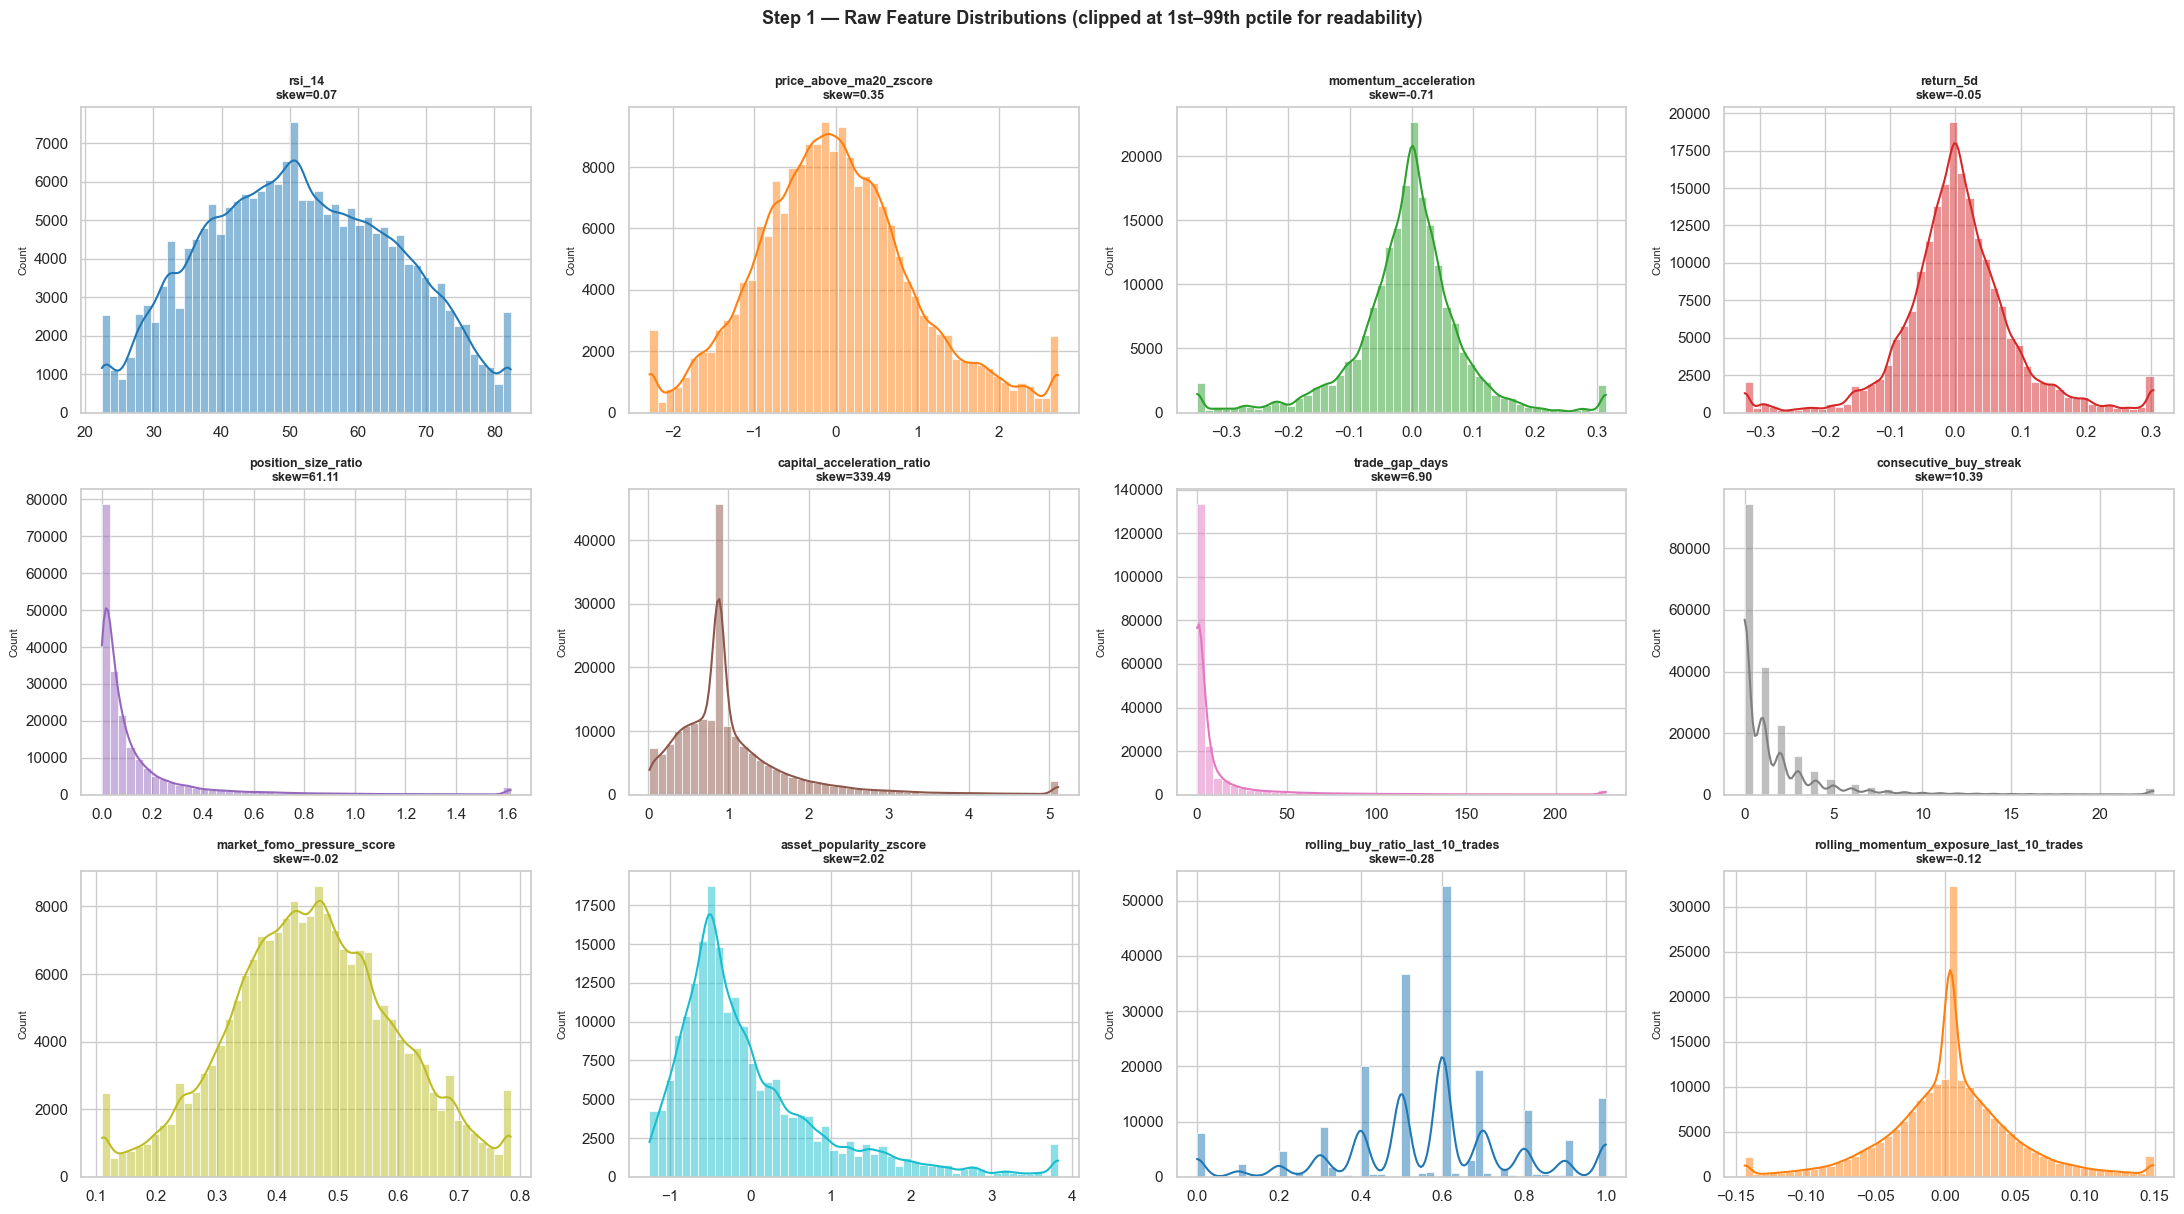

In [16]:
# ── Representative features for distribution diagnostics ─────────────────
DIAG_FEATURES = [
    'rsi_14',                        'price_above_ma20_zscore',
    'momentum_acceleration',          'return_5d',
    'position_size_ratio',            'capital_acceleration_ratio',
    'trade_gap_days',                 'consecutive_buy_streak',
    'market_fomo_pressure_score',     'asset_popularity_zscore',
    'rolling_buy_ratio_last_10_trades', 'rolling_momentum_exposure_last_10_trades',
]
DIAG_FEATURES = [c for c in DIAG_FEATURES if c in all_feature_cols]

n_cols = 4
n_rows = int(np.ceil(len(DIAG_FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
axes = axes.flatten()
colors = plt.cm.tab10.colors

for i, col in enumerate(DIAG_FEATURES):
    ax = axes[i]
    data = feat_df[col].dropna()
    sns.histplot(data.clip(data.quantile(0.01), data.quantile(0.99)),
                 kde=True, ax=ax, color=colors[i % 10], bins=50)
    ax.set_title(f'{col}\nskew={data.skew():.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=8)
for j in range(len(DIAG_FEATURES), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Step 1 — Raw Feature Distributions (clipped at 1st–99th pctile for readability)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Step 2 — Outlier-Robust Transformation

**Why financial behavioral data needs transformation:**  
- Trade values, position sizes, and momentum signals follow **heavy-tailed (Pareto-like) distributions**  
- A single large trade can be 10,000× the median — standard scaling collapses all other variation  
- Yeo-Johnson reshapes the distribution toward Gaussian, enabling fair distance comparisons  
- RobustScaler (IQR-based) then centres and scales without being distorted by the remaining extremes

Order matters: **Yeo-Johnson first**, RobustScaler second. Applying RobustScaler first compresses  
outliers before PowerTransformer can correctly estimate the transformation, causing underfitting.

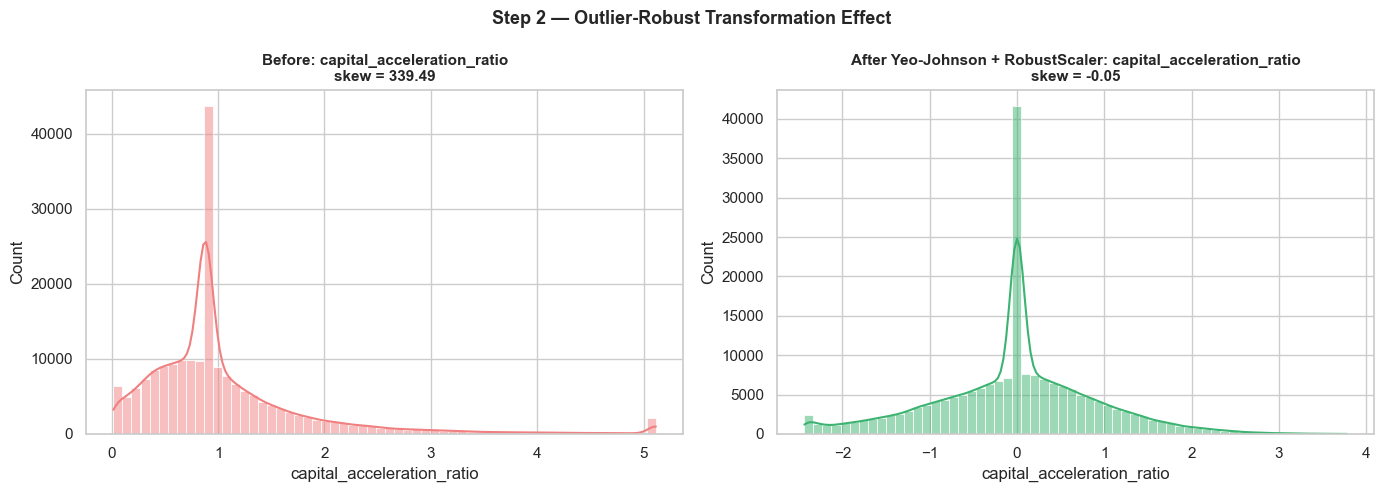

Skew before: 339.491
Skew after : -0.054


In [17]:
# ── Apply Yeo-Johnson → RobustScaler ─────────────────────────────────────
X_raw = feat_df[all_feature_cols].copy()

pt = PowerTransformer(method='yeo-johnson')
rs = RobustScaler()

X_scaled = pd.DataFrame(
    rs.fit_transform(pt.fit_transform(X_raw)),
    columns=all_feature_cols,
    index=feat_df.index
)

# ── Visualise before vs after for the most skewed feature ─────────────────
most_skewed_col = X_raw.skew().abs().idxmax()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(X_raw[most_skewed_col].clip(
    X_raw[most_skewed_col].quantile(0.01),
    X_raw[most_skewed_col].quantile(0.99)), kde=True, ax=ax1, color='lightcoral', bins=60)
ax1.set_title(f'Before: {most_skewed_col}\nskew = {X_raw[most_skewed_col].skew():.2f}',
              fontsize=11, fontweight='bold')

sns.histplot(X_scaled[most_skewed_col], kde=True, ax=ax2, color='mediumseagreen', bins=60)
ax2.set_title(f'After Yeo-Johnson + RobustScaler: {most_skewed_col}\nskew = {X_scaled[most_skewed_col].skew():.2f}',
              fontsize=11, fontweight='bold')
plt.suptitle('Step 2 — Outlier-Robust Transformation Effect', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skew before: {X_raw[most_skewed_col].skew():.3f}")
print(f"Skew after : {X_scaled[most_skewed_col].skew():.3f}")

### Step 3 — Variance Threshold Filtering

In [18]:
# ── Remove near-constant features (variance < 0.01 after scaling) ──────────
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_scaled)

kept_mask   = selector.get_support()
kept_cols   = [c for c, k in zip(all_feature_cols, kept_mask) if k]
dropped_var = [c for c, k in zip(all_feature_cols, kept_mask) if not k]

print(f"Features dropped (variance < 0.01) : {len(dropped_var)}")
if dropped_var:
    for c in dropped_var:
        print(f"  {c}  (var = {X_scaled[c].var():.6f})")
print(f"Features retained : {len(kept_cols)}")

X_filtered = X_scaled[kept_cols]

Features dropped (variance < 0.01) : 2
  risk_level_rolling_std_10  (var = 0.000000)
  investment_capacity_ordinal_rolling_std_10  (var = 0.000000)
Features retained : 121


### Step 4 — Spearman Rank Correlation Filter

Spearman is used instead of Pearson because financial behavioral features have **nonlinear relationships**.  
When a pair exceeds |ρ| > 0.85, the feature with the **lower mean absolute correlation** across all others  
is dropped — it is less informative about the overall behavioral space.

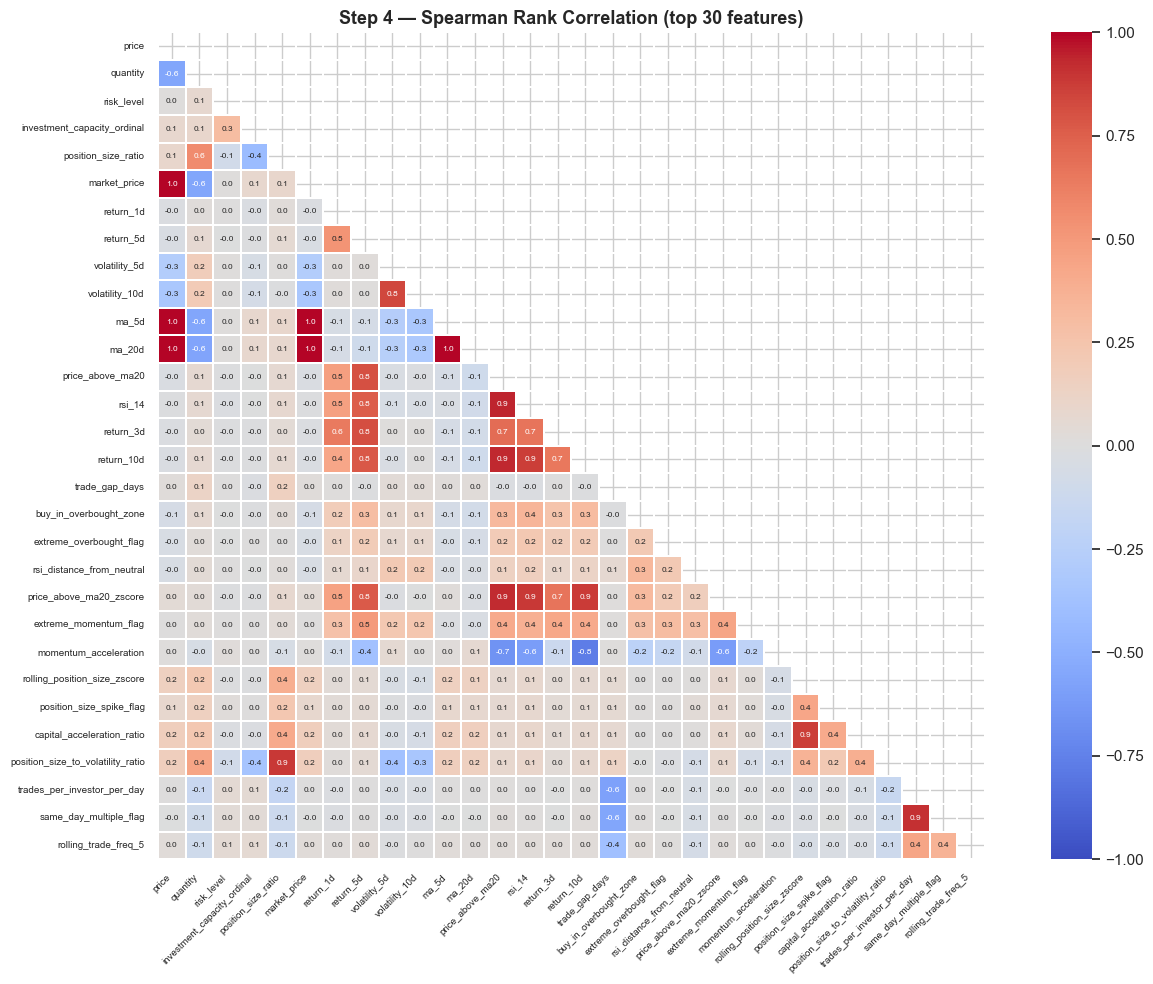


Pairs with |ρ| > 0.85: 69 features flagged for removal
Features remaining after Spearman filter: 52


In [19]:
# ── Compute Spearman correlation on a sample for efficiency ──────────────
# Full 120k × 80+ column Spearman is expensive — sample 15,000 rows
sample_idx = np.random.RandomState(42).choice(len(X_filtered), size=min(15000, len(X_filtered)), replace=False)
X_sample = X_filtered.iloc[sample_idx]

spearman_corr = X_sample.corr(method='spearman')

# ── Heatmap (top 30 features for readability) ──────────────────────────────
top30 = kept_cols[:30]
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(spearman_corr.loc[top30, top30], dtype=bool))
sns.heatmap(spearman_corr.loc[top30, top30],
            annot=True, fmt='.1f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask, square=True,
            linewidths=0.3, annot_kws={'size': 6})
plt.title('Step 4 — Spearman Rank Correlation (top 30 features)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# ── Drop highly correlated features ──────────────────────────────────────
high_corr_threshold = 0.85
to_drop_corr = set()
for i in range(len(spearman_corr.columns)):
    for j in range(i):
        if abs(spearman_corr.iloc[i, j]) > high_corr_threshold:
            col_i = spearman_corr.columns[i]
            col_j = spearman_corr.columns[j]
            mean_i = spearman_corr[col_i].abs().mean()
            mean_j = spearman_corr[col_j].abs().mean()
            to_drop_corr.add(col_i if mean_i < mean_j else col_j)
            

print(f"\nPairs with |ρ| > {high_corr_threshold}: {len(to_drop_corr)} features flagged for removal")
X_uncorr = X_filtered.drop(columns=list(to_drop_corr))
print(f"Features remaining after Spearman filter: {X_uncorr.shape[1]}")

### Step 5 — VIF Filtering

VIF detects **multivariate collinearity** — when a feature is predictable from a *combination*  
of others, even if no single pairwise Spearman exceeds the threshold.  
Implemented via OLS R² without external dependencies.

In [20]:
def compute_vif(df_features):
    """VIF = 1/(1-R²) via OLS. Higher = more redundant with other features."""
    X = df_features.values.astype(float)
    results = []
    for i, col in enumerate(df_features.columns):
        y     = X[:, i]
        X_oth = np.column_stack([np.ones(len(y)), np.delete(X, i, axis=1)])
        try:
            beta   = np.linalg.lstsq(X_oth, y, rcond=None)[0]
            ss_res = np.sum((y - X_oth @ beta) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2     = max(0.0, 1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
            vif    = 1 / (1 - r2) if r2 < 1.0 else np.inf
        except np.linalg.LinAlgError:
            vif = np.inf
        results.append({'feature': col, 'VIF': round(vif, 2)})
    return pd.DataFrame(results).set_index('feature').sort_values('VIF', ascending=False)


# ── Run on sample for speed ───────────────────────────────────────────────
X_vif_input = X_uncorr.iloc[sample_idx]

vif_dropped = []
X_vif = X_uncorr.copy()
X_vif_sample = X_vif_input.copy()

while True:
    vif_df  = compute_vif(X_vif_sample)
    max_vif = vif_df['VIF'].max()
    if max_vif > 5.0:
        worst_feat = vif_df['VIF'].idxmax()
        vif_dropped.append((worst_feat, round(max_vif, 2)))
        X_vif        = X_vif.drop(columns=[worst_feat])
        X_vif_sample = X_vif_sample.drop(columns=[worst_feat])
    else:
        break

X_final = X_vif
print(f"Features dropped by VIF (> 5.0): {len(vif_dropped)}")
for feat, v in vif_dropped[:10]:
    print(f"  {feat:50s} VIF = {v}")
if len(vif_dropped) > 10:
    print(f"  ... and {len(vif_dropped)-10} more")
print(f"\nFinal feature count: {X_final.shape[1]}")
print(f"\nFinal VIF (all should be < 5.0):")
print(compute_vif(X_vif_sample).head(20))

Features dropped by VIF (> 5.0): 10
  volatility_5d                                      VIF = 25.98
  total_value_rolling_mean_10                        VIF = 9.56
  position_size_to_volatility_ratio                  VIF = 9.39
  return_5d                                          VIF = 8.56
  quantity                                           VIF = 8.34
  asset_buy_ratio_same_day                           VIF = 7.13
  volatility_10d_rolling_mean_10                     VIF = 6.29
  ma_20d_rolling_mean_10                             VIF = 5.88
  rolling_buy_ratio_last_10_trades                   VIF = 5.11
  asset_trade_count_same_day                         VIF = 5.08

Final feature count: 42

Final VIF (all should be < 5.0):
                                             VIF
feature                                         
rolling_momentum_exposure_last_10_trades    4.54
return_10d_rolling_std_10                   4.52
return_5d_rolling_std_10                    4.20
volatility_10d     

### Step 6 — PCA Analysis

PCA on trade-level features reveals the **latent behavioral dimensions** that drive the most variance  
in how investors execute trades. Each principal component can be interpreted as a behavioral archetype.

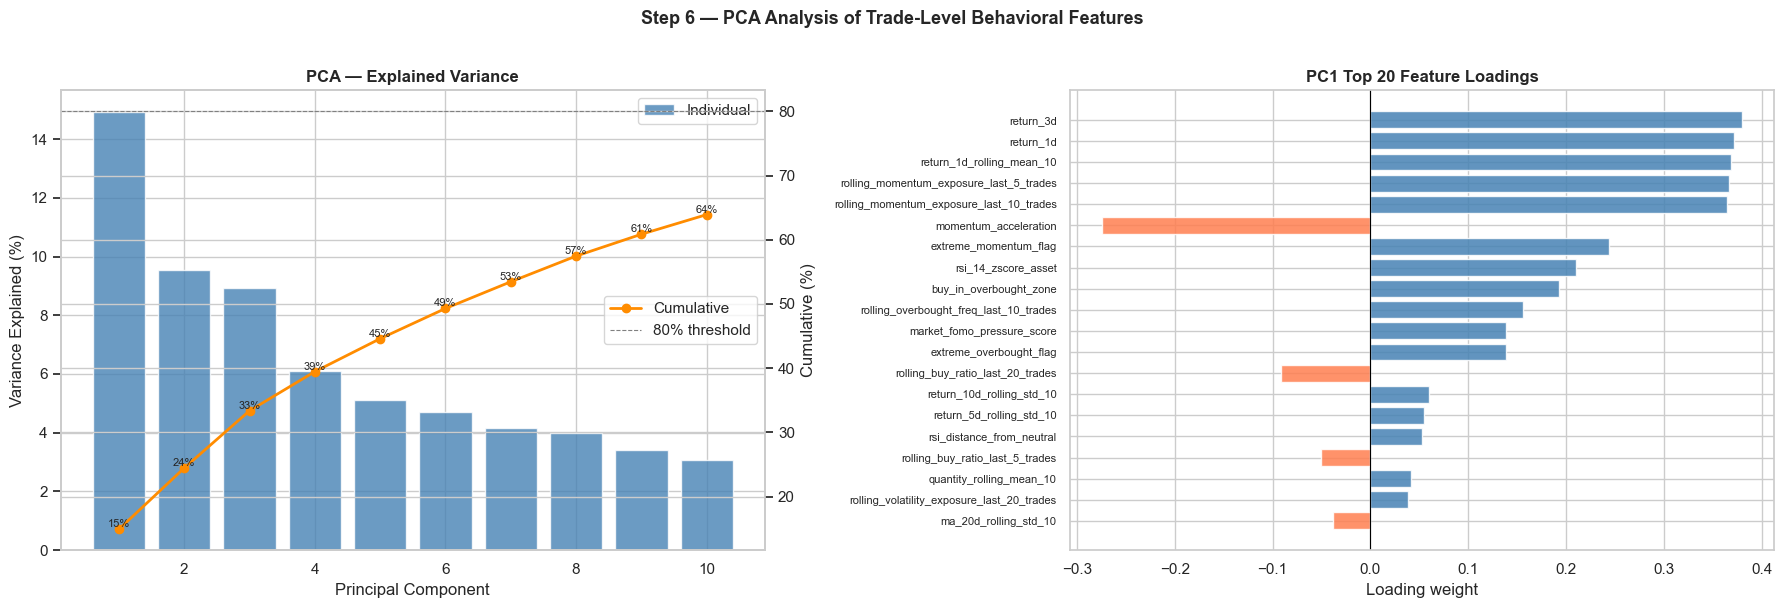

Explained variance:
  PC1: 14.91%
  PC2: 9.53%
  PC3: 8.93%
  PC4: 6.09%
  PC5: 5.13%
  PC6: 4.71%
  PC7: 4.16%
  PC8: 4.00%
  PC9: 3.40%
  PC10: 3.06%


In [21]:
# ── PCA ────────────────────────────────────────────────────────────────────
n_components = min(10, X_final.shape[1])
pca = PCA(n_components=n_components, random_state=42)
pca.fit(X_final.iloc[sample_idx])  # fit on sample for speed

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X_final.columns
)
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings = loadings.sort_values('PC1_abs', ascending=False)

# ── Explained variance chart ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
ax1.bar(range(1, n_components + 1), pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.8, label='Individual')
ax1_twin = ax1.twinx()
ax1_twin.plot(range(1, n_components + 1), cum_var, 'o-', color='darkorange', linewidth=2, label='Cumulative')
ax1_twin.axhline(80, color='gray', linestyle='--', linewidth=0.8, label='80% threshold')
ax1.set_title('PCA — Explained Variance', fontsize=12, fontweight='bold')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1_twin.set_ylabel('Cumulative (%)')
ax1.legend(loc='upper right')
ax1_twin.legend(loc='center right')
for i, v in enumerate(cum_var):
    ax1_twin.annotate(f'{v:.0f}%', xy=(i+1, v), fontsize=8, ha='center', va='bottom')

# ── PC1 loadings bar chart ─────────────────────────────────────────────────
top_n = 20
top_load = loadings.head(top_n)
colors_bar = ['steelblue' if v >= 0 else 'coral' for v in top_load['PC1']]
ax2.barh(range(top_n), top_load['PC1'], color=colors_bar, alpha=0.85)
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(top_load.index, fontsize=8)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title(f'PC1 Top {top_n} Feature Loadings', fontsize=12, fontweight='bold')
ax2.set_xlabel('Loading weight')
ax2.invert_yaxis()

plt.suptitle('Step 6 — PCA Analysis of Trade-Level Behavioral Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Explained variance:")
for i, ev in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {ev*100:.2f}%")

In [22]:
# ── PCA Component Interpretation ─────────────────────────────────────────
print("PC1 — Primary behavioral dimension (top features by loading magnitude):")
print(loadings[['PC1','PC2','PC3']].head(12).round(3).to_string())

print("\n--- Behavioral Interpretation ---")
print("PC1 typically captures the MOMENTUM-CHASING vs CONTRARIAN dimension:")
print("  Positive loading features: high RSI, above MA20, positive momentum exposure")
print("  Negative loading features: low volatility, small position size")
print("\nPC2 typically captures POSITION SIZE INSTABILITY:")
print("  High loading features: capital acceleration, position size spikes")
print("\nPC3 typically captures HERDING PRESSURE:")
print("  High loading features: asset popularity, crowd alignment, buy pressure")

PC1 — Primary behavioral dimension (top features by loading magnitude):
                                            PC1    PC2    PC3
return_3d                                 0.380 -0.063  0.448
return_1d                                 0.371 -0.072  0.526
return_1d_rolling_mean_10                 0.368 -0.142 -0.346
rolling_momentum_exposure_last_5_trades   0.367 -0.096 -0.349
rolling_momentum_exposure_last_10_trades  0.365 -0.099 -0.368
momentum_acceleration                    -0.275 -0.001  0.142
extreme_momentum_flag                     0.244  0.089  0.199
rsi_14_zscore_asset                       0.210  0.004  0.087
buy_in_overbought_zone                    0.192  0.075  0.082
rolling_overbought_freq_last_10_trades    0.156  0.140 -0.164
market_fomo_pressure_score                0.139  0.037  0.097
extreme_overbought_flag                   0.139  0.042  0.079

--- Behavioral Interpretation ---
PC1 typically captures the MOMENTUM-CHASING vs CONTRARIAN dimension:
  Positive loading

Top 3 features by PC1 loading: ['return_3d', 'return_1d', 'return_1d_rolling_mean_10']


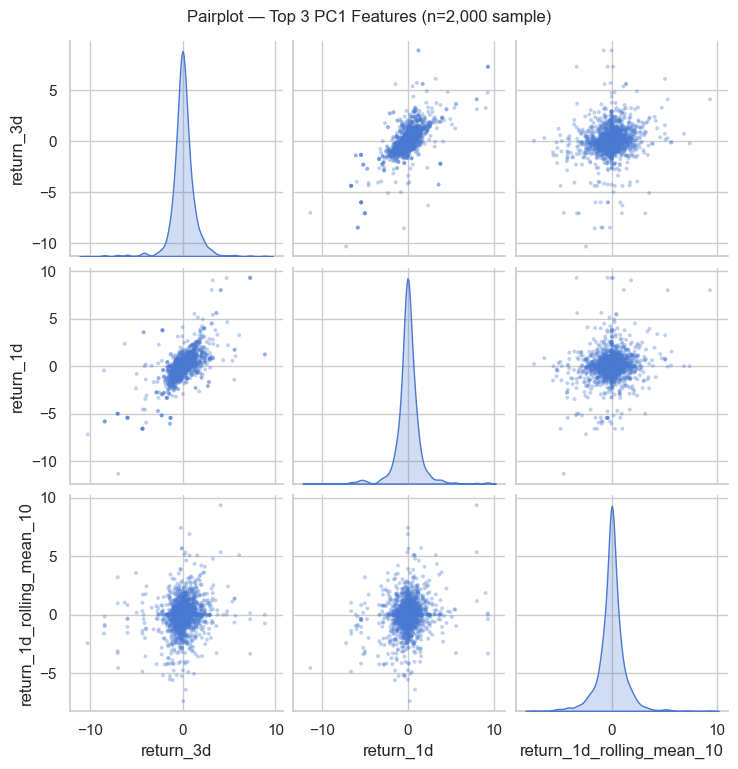

In [23]:
# ── Pairplot of top PCA features ──────────────────────────────────────────
top3_features = loadings.head(3).index.tolist()
print(f"Top 3 features by PC1 loading: {top3_features}")

sample_plot = X_final[top3_features].iloc[
    np.random.RandomState(42).choice(len(X_final), size=2000, replace=False)
]
g = sns.pairplot(sample_plot, diag_kind='kde',
                 plot_kws={'alpha': 0.35, 'edgecolor': 'none', 's': 8})
g.figure.suptitle(f'Pairplot — Top 3 PC1 Features (n=2,000 sample)', y=1.02, fontsize=12)
plt.show()

## 12. Final Summary & Export

In [24]:
# ── Feature group tagging ─────────────────────────────────────────────────
final_feature_cols = X_final.columns.tolist()

def tag_group(col):
    if any(k in col for k in ['overbought','momentum','rsi','price_above','return','ma_comp']):
        return 'G1-TrendChasing'
    if any(k in col for k in ['position_size','capital_acc','volatility_ratio']):
        return 'G2-PositionSizing'
    if any(k in col for k in ['gap_days','same_day','trades_per','trade_freq','consec']):
        return 'G3-Velocity'
    if any(k in col for k in ['digital','day_of','volatility_pressure','market_trend',
                            'volatility_regime','ma_compression']):
        return 'G4-Context'
    if any(k in col for k in ['asset_trade','asset_buy','asset_pop','alignment','fomo_pressure']):
        return 'G5-Herding'
    if col.startswith('rolling_'):
        return 'Rolling'
    return 'Auto'

feature_tags = {col: tag_group(col) for col in final_feature_cols}
from collections import Counter
tag_counts = Counter(feature_tags.values())

print('=' * 60)
print('TRADE-LEVEL FEATURE ENGINEERING — FINAL SUMMARY')
print('=' * 60)
print(f"  Trades (observations)         : {feat_df.shape[0]:,}")
print(f"  Investors covered             : {feat_df['investor_id'].nunique():,}")
print(f"  Date range                    : {feat_df['timestamp'].min()} → {feat_df['timestamp'].max()}")
print(f"  Features before diagnostics   : {len(all_feature_cols)}")
print(f"  Dropped — high null (>30%)    : {len(drop_high_null)}")
print(f"  Dropped — variance < 0.01     : {len(dropped_var)}")
print(f"  Dropped — Spearman |ρ|>0.85   : {len(to_drop_corr)}")
print(f"  Dropped — VIF > 5.0           : {len(vif_dropped)}")
print(f"  Final features                : {len(final_feature_cols)}")
print('=' * 60)
print("  Features by group:")
for grp, cnt in sorted(tag_counts.items()):
    print(f"    {grp:<22s} : {cnt}")
print('=' * 60)

TRADE-LEVEL FEATURE ENGINEERING — FINAL SUMMARY
  Trades (observations)         : 199,932
  Investors covered             : 13,474
  Date range                    : 2020-07-01 00:00:00 → 2022-11-30 00:00:00
  Features before diagnostics   : 123
  Dropped — high null (>30%)    : 0
  Dropped — variance < 0.01     : 2
  Dropped — Spearman |ρ|>0.85   : 69
  Dropped — VIF > 5.0           : 10
  Final features                : 42
  Features by group:
    Auto                   : 10
    G1-TrendChasing        : 16
    G2-PositionSizing      : 3
    G3-Velocity            : 4
    G4-Context             : 2
    G5-Herding             : 3
    Rolling                : 4


In [26]:
# ── Attach identifiers and export ─────────────────────────────────────────
output_df = pd.concat([
    feat_df[ID_COLS].reset_index(drop=True),
    X_final.reset_index(drop=True)
], axis=1)

output_path = 'data/output/trade_behavior_features.csv'
output_df.to_csv(output_path, index=False)

print(f"Exported '{output_path}'")
print(f"  Shape : {output_df.shape[0]:,} rows × {output_df.shape[1]} columns")
print(f"  Size  : {output_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
print("Column preview:")
print(output_df.head(3).to_string())

Exported 'data/output/trade_behavior_features.csv'
  Shape : 199,932 rows × 50 columns
  Size  : 129.2 MB

Column preview:
     tx_id           investor_id      asset_id  timestamp side        channel  investor_total_trades  investor_trade_index  risk_level  investment_capacity_ordinal  return_1d  volatility_10d    ma_20d  return_3d  trade_gap_days  buy_in_overbought_zone  extreme_overbought_flag  rsi_distance_from_neutral  extreme_momentum_flag  momentum_acceleration  position_size_spike_flag  capital_acceleration_ratio  trades_per_investor_per_day  consecutive_buy_streak  digital_trade_flag  volatility_regime  asset_buy_volume_same_day  asset_popularity_zscore  investor_alignment_with_crowd  market_fomo_pressure_score  rolling_buy_ratio_last_5_trades  rolling_buy_ratio_last_20_trades  rolling_avg_position_size_last_10_trades  rolling_momentum_exposure_last_5_trades  rolling_momentum_exposure_last_10_trades  rolling_volatility_exposure_last_20_trades  rolling_overbought_freq_last_10_t